In [1]:
# gan over mnist

import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import time
from IPython import display

# Load MNIST
(train_images, train_labels), (_, _) = tf.keras.datasets.mnist.load_data()

# Preprocess Images: Reshape and Normalize to [-1, 1]
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5

# Preprocess Labels: Reshape for the Embedding layer
train_labels = train_labels.reshape(-1, 1).astype('int32')

# Create Dataset
BUFFER_SIZE = 60000
BATCH_SIZE = 256
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels)).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [2]:
def make_generator_model():
    noise_in = layers.Input(shape=(100,))
    label_in = layers.Input(shape=(1,))

    # Label pathway
    le = layers.Embedding(10, 50)(label_in)
    le = layers.Dense(7 * 7)(le)
    le = layers.Reshape((7, 7, 1))(le)

    # Noise pathway
    n = layers.Dense(7 * 7 * 256, use_bias=False)(noise_in)
    n = layers.BatchNormalization()(n)
    n = layers.LeakyReLU()(n)
    n = layers.Reshape((7, 7, 256))(n)

    # Merge
    merged = layers.Concatenate()([n, le])

    # Upsample
    x = layers.Conv2DTranspose(128, (4, 4), strides=(1, 1), padding='same', use_bias=False)(merged)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(64, (4, 4), strides=(2, 2), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    out = layers.Conv2DTranspose(1, (4, 4), strides=(2, 2), padding='same', use_bias=False, activation='tanh')(x)

    return Model(inputs=[noise_in, label_in], outputs=out)

generator = make_generator_model()

In [3]:
def make_discriminator_model():
    img_in = layers.Input(shape=(28, 28, 1))
    label_in = layers.Input(shape=(1,))

    # Label pathway
    le = layers.Embedding(10, 50)(label_in)
    le = layers.Dense(28 * 28)(le)
    le = layers.Reshape((28, 28, 1))(le)

    # Merge Image + Label map
    merged = layers.Concatenate()([img_in, le])

    x = layers.Conv2D(64, (4, 4), strides=(2, 2), padding='same')(merged)
    x = layers.BatchNormalization()(x) # Added BatchNormalization
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, (4, 4), strides=(2, 2), padding='same')(x)
    x = layers.BatchNormalization()(x) # Added BatchNormalization
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)
    out = layers.Dense(1)(x)

    return Model(inputs=[img_in, label_in], outputs=out)

discriminator = make_discriminator_model()

In [5]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output) * 0.9, real_output) # Smoothing
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-5, beta_1=0.5)

In [6]:
@tf.function
def train_step(images, labels):
    noise = tf.random.normal([BATCH_SIZE, 100])
    random_labels = tf.random.uniform([BATCH_SIZE, 1], minval=0, maxval=10, dtype=tf.int32)

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator([noise, random_labels], training=True)

        real_output = discriminator([images, labels], training=True)
        fake_output = discriminator([generated_images, random_labels], training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

# Visualization Seed: Shows digits 0-9 specifically
num_examples_to_generate = 16
seed_noise = tf.random.normal([num_examples_to_generate, 100])
seed_labels = tf.constant([[i % 10] for i in range(num_examples_to_generate)], dtype=tf.int32)

def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')
    plt.suptitle(f'Epoch {epoch}')
    plt.show()

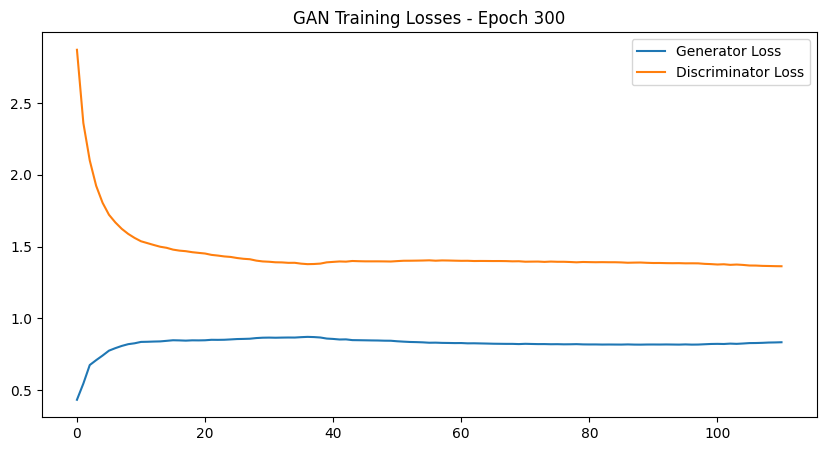

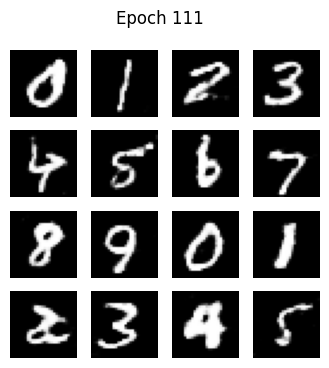

In [ ]:
gen_losses = []
disc_losses = []

def plot_losses(gen_losses, disc_losses, epoch):
    # display.clear_output(wait=True) <-- REMOVED this to prevent deleting old charts
    plt.figure(figsize=(10, 5))
    plt.plot(gen_losses, label='Generator Loss')
    plt.plot(disc_losses, label='Discriminator Loss')
    plt.title(f"GAN Training Losses - Epoch {epoch}")
    plt.legend()
    plt.show()

def train(dataset, epochs):
    for epoch in range(epochs):
        epoch_gen_loss = []
        epoch_disc_loss = []

        for image_batch, label_batch in dataset:
            g_loss, d_loss = train_step(image_batch, label_batch)
            epoch_gen_loss.append(g_loss)
            epoch_disc_loss.append(d_loss)

        gen_losses.append(tf.reduce_mean(epoch_gen_loss))
        disc_losses.append(tf.reduce_mean(epoch_disc_loss))

        # Update plots
        display.clear_output(wait=True)
        plot_losses(gen_losses, disc_losses,300)
        generate_and_save_images(generator, epoch + 1, [seed_noise, seed_labels])

train(train_dataset, 300)

In [ ]:
import matplotlib.pyplot as plt

# Create a consistent seed so we can see how the SAME images improve over time
seed = tf.random.normal([16, 100])

def generate_and_save_images(model, epoch, test_input):
    # 'training' is set to False so layers like BatchNormalization run in inference mode
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        # Rescale from [-1, 1] back to [0, 1] for display
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.savefig(f'image_at_epoch_{epoch:04d}.png')
    plt.show()